In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

niketh364_drones_with_occlusionsdut_anti_uav_path = kagglehub.dataset_download('niketh364/drones-with-occlusionsdut-anti-uav')

print('Data source import complete.')


In [ ]:
!pip install ultralytics
!pip install opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 20.8 MB/s eta 0:00:00a 0:00:01


In [ ]:
import os
import shutil
import xml.etree.ElementTree as ET
from tqdm import tqdm

In [ ]:
DATA_PATH = "/kaggle/input/datasets/niketh364/drones-with-occlusionsdut-anti-uav"

TRAIN_IMG = f"{DATA_PATH}/train/train/img"
TRAIN_XML = f"{DATA_PATH}/train/train/xml"

VAL_IMG = f"{DATA_PATH}/val/val/img"
VAL_XML = f"{DATA_PATH}/val/val/xml"

TEST_IMG = f"{DATA_PATH}/test/test/img"
TEST_XML = f"{DATA_PATH}/test/test/xml"

WORK_DIR = "/kaggle/working/dataset"

In [ ]:
for split in ["train","val","test"]:
    os.makedirs(f"{WORK_DIR}/images/{split}", exist_ok=True)
    os.makedirs(f"{WORK_DIR}/labels/{split}", exist_ok=True)

print("YOLO dataset structure created")

YOLO dataset structure created


In [ ]:
def copy_images(src, dst):
    for img in os.listdir(src):
        shutil.copy(os.path.join(src,img), dst)

copy_images(TRAIN_IMG, WORK_DIR+"/images/train")
copy_images(VAL_IMG, WORK_DIR+"/images/val")
copy_images(TEST_IMG, WORK_DIR+"/images/test")

print("Images copied")

Images copied


In [ ]:
def convert_xml_to_yolo(xml_dir, img_dir, label_dir):

    for xml_file in tqdm(os.listdir(xml_dir)):

        tree = ET.parse(os.path.join(xml_dir, xml_file))
        root = tree.getroot()

        size = root.find("size")
        w = int(size.find("width").text)
        h = int(size.find("height").text)

        yolo_lines = []

        for obj in root.findall("object"):

            cls_id = 0  # only class: drone

            box = obj.find("bndbox")

            xmin = float(box.find("xmin").text)
            ymin = float(box.find("ymin").text)
            xmax = float(box.find("xmax").text)
            ymax = float(box.find("ymax").text)

            x_center = ((xmin + xmax)/2)/w
            y_center = ((ymin + ymax)/2)/h
            width = (xmax - xmin)/w
            height = (ymax - ymin)/h

            yolo_lines.append(f"{cls_id} {x_center} {y_center} {width} {height}\n")

        label_path = os.path.join(label_dir, xml_file.replace(".xml",".txt"))

        with open(label_path,"w") as f:
            f.writelines(yolo_lines)

In [ ]:
convert_xml_to_yolo(TRAIN_XML, TRAIN_IMG, WORK_DIR+"/labels/train")
convert_xml_to_yolo(VAL_XML, VAL_IMG, WORK_DIR+"/labels/val")
convert_xml_to_yolo(TEST_XML, TEST_IMG, WORK_DIR+"/labels/test")

print("Annotation conversion complete")

100%|██████████| 2200/2200 [00:12<00:00, 172.67it/s]

Annotation conversion complete


In [ ]:
yaml_content = f"""
path: {WORK_DIR}

train: images/train
val: images/val
test: images/test

names:
  0: drone
"""

with open(f"{WORK_DIR}/drone.yaml","w") as f:
    f.write(yaml_content)

print("drone.yaml created")

drone.yaml created


In [ ]:
import os

print("Datasets available in /kaggle/input:\n")

for folder in os.listdir("/kaggle/input"):
    print(folder)

Datasets available in /kaggle/input:

datasets


In [ ]:
from ultralytics import RTDETR

model = RTDETR("rtdetr-l.pt")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
model.train(
    data=f"{WORK_DIR}/drone.yaml",
    epochs=10,
    imgsz=640,
    batch=8
)

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/dataset/drone.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=rtdetr-l.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspec

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:841: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:157.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       1/10      6.52G      0.692      1.244     0.1263          9        640: 100% ━━━━━━━━━━━━ 650/650 1.6it/s 6:42<0.6s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 163/163 3.0it/s 53.9s0.3ss
                   all       2600       2621      0.899      0.784      0.831       0.47

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
       2/10         7G     0.4678     0.5019    0.02948          7        640: 0% ──────────── 0/650  0.6s

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:841: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:157.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       2/10         7G     0.6206      0.469      0.089          8        640: 100% ━━━━━━━━━━━━ 650/650 1.7it/s 6:32<0.6s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 163/163 3.2it/s 51.3s0.3ss
                   all       2600       2621      0.917      0.759      0.837      0.472

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
       3/10      7.09G     0.5456     0.3959    0.02942          8        640: 0% ──────────── 0/650  0.7s

...

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:841: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:157.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       9/10      7.26G     0.4929     0.4284    0.06274          7        640: 100% ━━━━━━━━━━━━ 650/650 1.7it/s 6:26<0.6s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 163/163 3.2it/s 51.7s0.3ss
                   all       2600       2621       0.96      0.866      0.916      0.597

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
      10/10      6.79G     0.4498     0.4554    0.03028          7        640: 0% ──────────── 0/650  0.6s

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:841: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:157.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      10/10      6.79G     0.4682      0.412    0.05889          8        640: 100% ━━━━━━━━━━━━ 650/650 1.7it/s 6:26<0.6s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 163/163 3.1it/s 51.8s0.3ss
                   all       2600       2621      0.959      0.881      0.925      0.602

10 epochs completed in 1.227 hours.
Optimizer stripped from /kaggle/working/runs/detect/train/weights/last.pt, 66.2MB
Optimizer stripped from /kaggle/working/runs/detect/train/weights/best.pt, 66.2MB

Validating /kaggle/working/runs/detect/train/weights/best.pt...
Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
rt-detr-l summary: 310 layers, 31,985,795 parameters, 0 gradients, 103.4 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 163/163 3.2it/s 50.7s0.3ss
                   all       2600       2621      0.958       0.88      0.925      0.601
S

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7b863c086ed0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [ ]:
precision = float(metrics.box.p[0])
recall = float(metrics.box.r[0])
map50 = float(metrics.box.map50)
map5095 = float(metrics.box.map)

f1 = 2 * (precision * recall) / (precision + recall + 1e-6)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("mAP@0.5:", map50)
print("mAP@0.5:0.95:", map5095)

Precision: 0.9580675941805198
Recall: 0.8809614650896604
F1 Score: 0.9178975919068412
mAP@0.5: 0.9258170182957316
mAP@0.5:0.95: 0.6061356508804581


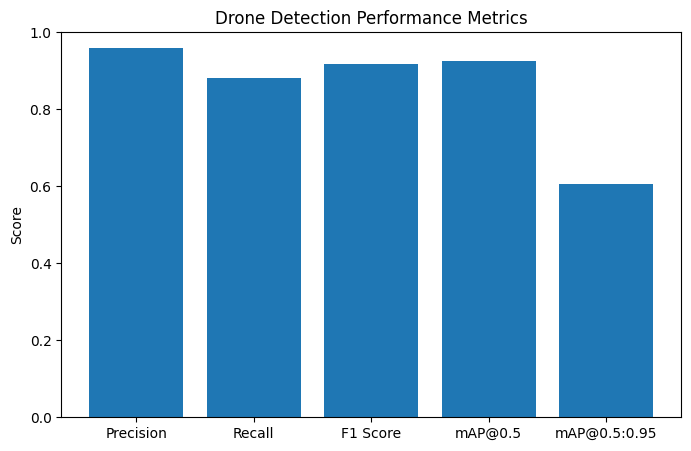

In [ ]:
import matplotlib.pyplot as plt

metric_names = ["Precision", "Recall", "F1 Score", "mAP@0.5", "mAP@0.5:0.95"]
metric_values = [precision, recall, f1, map50, map5095]

plt.figure(figsize=(8,5))
plt.bar(metric_names, metric_values)

plt.title("Drone Detection Performance Metrics")
plt.ylabel("Score")
plt.ylim(0,1)

plt.show()

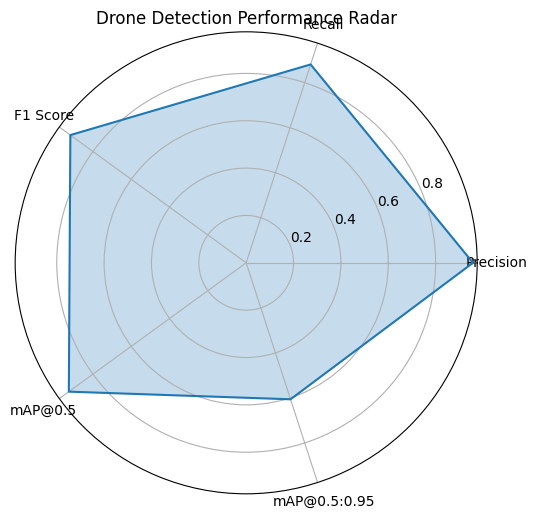

In [ ]:
import numpy as np

labels = np.array(metric_names)
values = np.array(metric_values)

angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False)
values = np.concatenate((values,[values[0]]))
angles = np.concatenate((angles,[angles[0]]))

fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, polar=True)

ax.plot(angles, values)
ax.fill(angles, values, alpha=0.25)

ax.set_thetagrids(angles[:-1]*180/np.pi, labels)

plt.title("Drone Detection Performance Radar")
plt.show()

In [ ]:
results = model.predict(
    source=f"{WORK_DIR}/images/test",
    conf=0.25,
    save=True
)


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

image 1/2200 /kaggle/working/dataset/images/test/00001.jpg: 640x640 1 drone, 59.0ms
image 2/2200 /kaggle/working/dataset/images/test/00002.jpg: 640x640 1 drone, 56.6ms
image 3/2200 /kaggle/working/dataset/images/test/00003.jpg: 640x640 1 drone, 52.8ms
image 4/2200 /kaggle/working/dataset/images/test/00004.jpg: 640x640 1 drone, 54.3ms
image 5/2200 /kaggle/working/dataset/images/test/00005.jpg: 640x640 1 drone, 50.7ms
image 6/2200 /kaggle/working/dataset/i

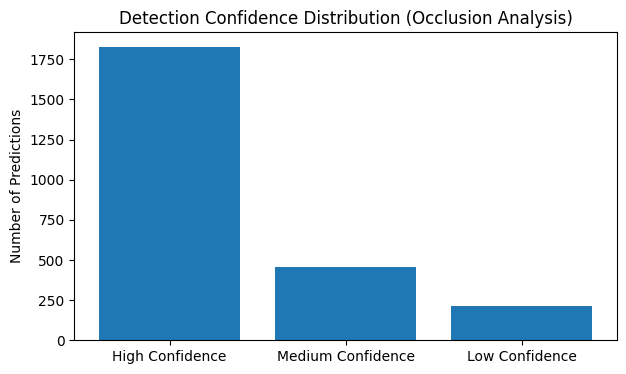

In [ ]:
conf_high = 0
conf_medium = 0
conf_low = 0

for r in results:

    if r.boxes is None:
        continue

    for box in r.boxes:

        conf = float(box.conf)

        if conf > 0.75:
            conf_high += 1
        elif conf > 0.4:
            conf_medium += 1
        else:
            conf_low += 1

labels = ["High Confidence", "Medium Confidence", "Low Confidence"]
values = [conf_high, conf_medium, conf_low]

plt.figure(figsize=(7,4))
plt.bar(labels, values)

plt.title("Detection Confidence Distribution (Occlusion Analysis)")
plt.ylabel("Number of Predictions")

plt.show()

In [ ]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 58.1 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=74d9969a4e8bdc9336976059e843713c82a52675594758fd134abfce241b5aae
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam
